# Octonet Demo
This Jupyter Notebook demonstrates how to 
1. download dataset
2. use data loader and data visualizer

## Data Download
To Download the dataset, 
1. Visit [OctoNet Webpage](https://aiot-lab.github.io/OctoNet/), and find the section "Generate Config.json";
2. Select the users, environments, modalities, and activities you need to download;
3. Download the generated `config.json` file
4. `python streaming.py --config_path config_download.json  --local_dir downloaded_data`
5. cd into the folder and unzip (see the shell script below)

In [5]:
%%bash
# cd into the folder which is download destination
cd downloaded_data

# unzip all zip files
find node_*/ -name "*.zip" -exec sh -c '
  for zip; do
    dir="${zip%.zip}"
    mkdir -p "$dir"
    unzip -j -o "$zip" -d "$dir"
  done
' _ {} +

# remove all zip files
find node_*/ -name "*.zip" -exec sh -c '
  for zip; do
    rm -f "$zip"
  done
' _ {} +

# return back to original level
cd ..

Archive:  node_1/1_acoustic_1_1_airdrum_1_20240519182852.zip
  inflating: node_1/1_acoustic_1_1_airdrum_1_20240519182852/20240519182853_node_1_modality_acoustic_subject_1_activity_airdrum_trial_1.wav  
  inflating: node_1/1_acoustic_1_1_airdrum_1_20240519182852/20240519182853_node_1_modality_acoustic_subject_1_activity_airdrum_trial_1.log  
  inflating: node_1/1_acoustic_1_1_airdrum_1_20240519182852/20240519182853_node_1_modality_acoustic_subject_1_activity_airdrum_trial_1.log  
  inflating: node_1/1_acoustic_1_1_airdrum_1_20240519182852/20240519182853_node_1_modality_acoustic_subject_1_activity_airdrum_trial_1.wav  
Archive:  node_1/1_depthcam_1_1_airdrum_1_20240519182852.zip
  inflating: node_1/1_depthcam_1_1_airdrum_1_20240519182852/depth_2024-05-19 18:29:34.420551.png  
  inflating: node_1/1_depthcam_1_1_airdrum_1_20240519182852/depth_2024-05-19 18:29:03.366234.png  
  inflating: node_1/1_depthcam_1_1_airdrum_1_20240519182852/depth_2024-05-19 18:30:00.925608.png  
  inflating: node

## Data loading and visualization

`load_recording(node_id=1)` loads one camera angle. A modality that was recorded on exactly one other node, such as ToF on node 4, is still included. RGB video is not opened.

The next cell loads the first middle cut. Each cell after that calls `show_keyframe` for one modality, and the picture is shown under that cell. The key frame is the middle depth frame of the cut.

Depth, Seek Thermal, IRA, and ToF show that frame with no axis labels. WiFi, Vayyar, UWB, audio, IMU, and Polar show the whole cut, with a scale on time and on the other axis. WiFi is two transmitter heatmaps. The mmWave cloud is the aligned frame drawn in 3D. The skeleton is the aligned pose, drawn at the figure resolution rather than as a small video frame.


In [12]:
from data_loader_new import iter_segments, load_recording

recording = load_recording(
    dataset_root="downloaded_data",
    metadata_csv="cut_manual.csv",
    user_id="1",
    activity="airdrum",
    timestamp="20240519182852",
    node_id=1,
)
print(
    f"user {recording['user_id']}, activity {recording['activity']}, "
    f"timestamp {recording['timestamp']}"
)
print(f"{len(recording['segments'])} middle cuts, missing: {recording['missing'] or 'none'}")
for name, streams in recording.items():
    if isinstance(streams, dict) and streams and "timestamps" not in streams:
        print(f"  {name}: nodes {sorted(streams)}")

start, end, clip = next(iter_segments(recording))
print(f"key frame from the first cut: {start} -> {end}")


objc[72423]: Class SDLApplication is implemented in both /Users/entomophile/mambaforge/envs/octonet_demo/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ddfc890) and /opt/homebrew/Cellar/sdl2/2.32.8/lib/libSDL2-2.0.0.dylib (0x152e0c890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[72423]: Class SDLAppDelegate is implemented in both /Users/entomophile/mambaforge/envs/octonet_demo/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ddfc8e0) and /opt/homebrew/Cellar/sdl2/2.32.8/lib/libSDL2-2.0.0.dylib (0x152e0c8e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[72423]: Class SDLTranslatorResponder is implemented in both /Users/entomophile/mambaforge/envs/octonet_demo/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11ddfc958) and /opt/homebrew/Cellar/sdl2/2.32.8/lib/libSDL2-2.0.0.dylib (0x152e0c

user 1, activity airdrum, timestamp 20240519182852
8 middle cuts, missing: none
  IRA: nodes [1]
  uwb: nodes [1]
  wifi: nodes [1]
  mmWave: nodes [1]
  polar: nodes [1]
  acoustic: nodes [1]
  seekThermal: nodes [1]
  depthCamera: nodes [1]
  vayyar: nodes [1]
  ToF: nodes [4]
key frame from the first cut: 2024-05-19 18:29:11.754000 -> 2024-05-19 18:29:19.087000


Matplotlib is building the font cache; this may take a moment.


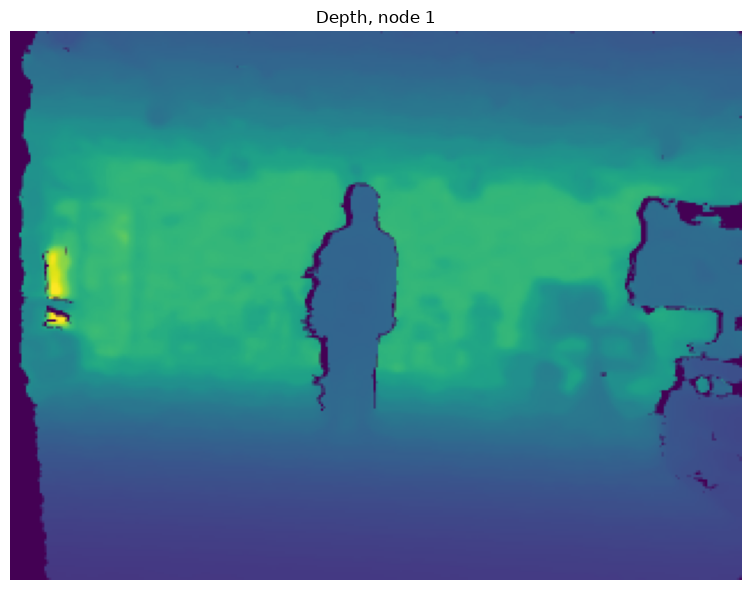

In [13]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'depth', 'Depth, node 1')


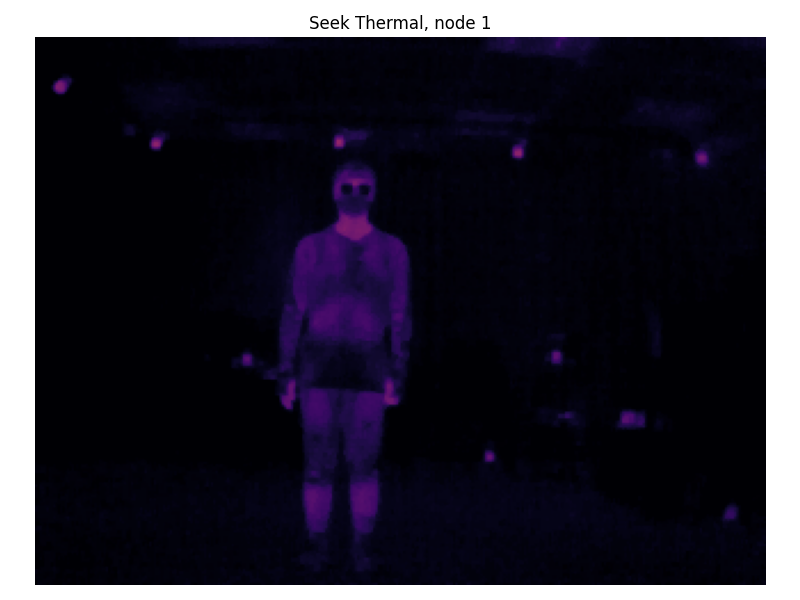

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'seek', 'Seek Thermal, node 1')


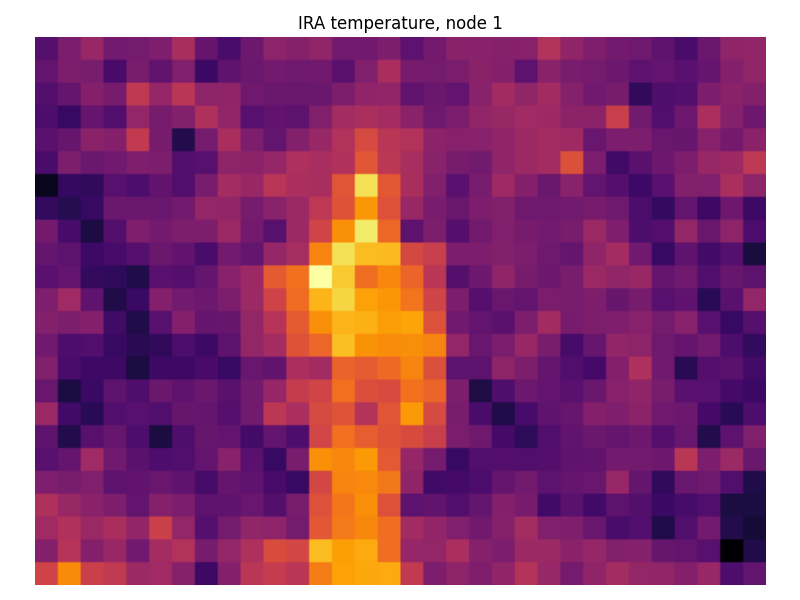

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'ira', 'IRA temperature, node 1')


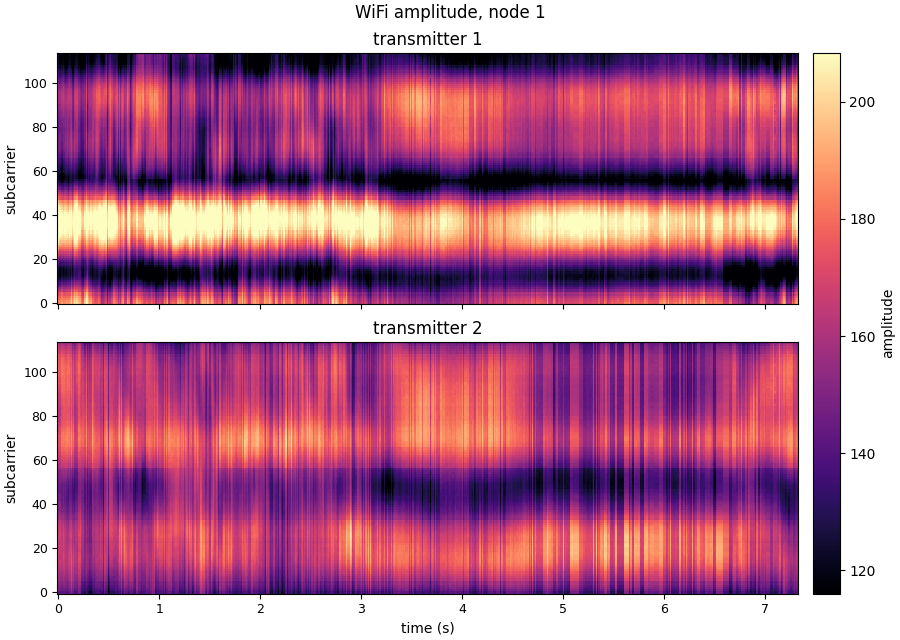

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'wifi', 'WiFi amplitude, node 1')


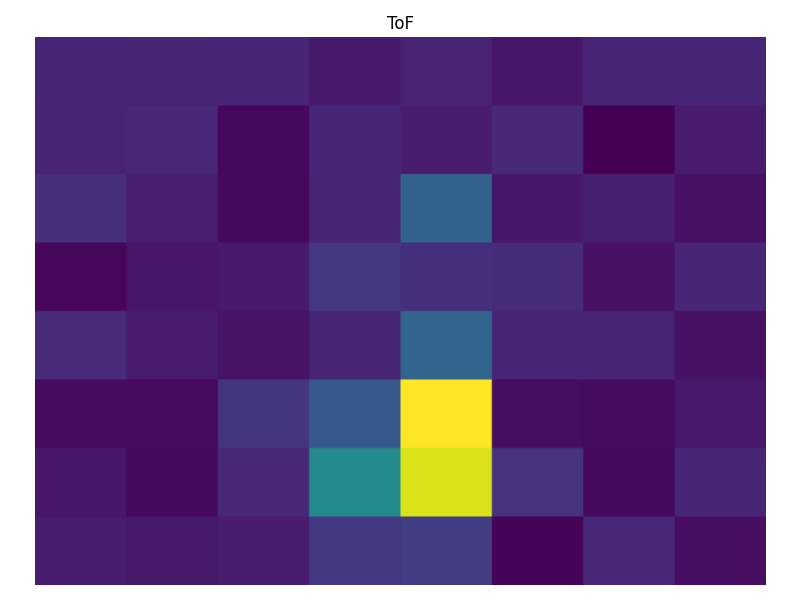

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'tof', 'ToF')


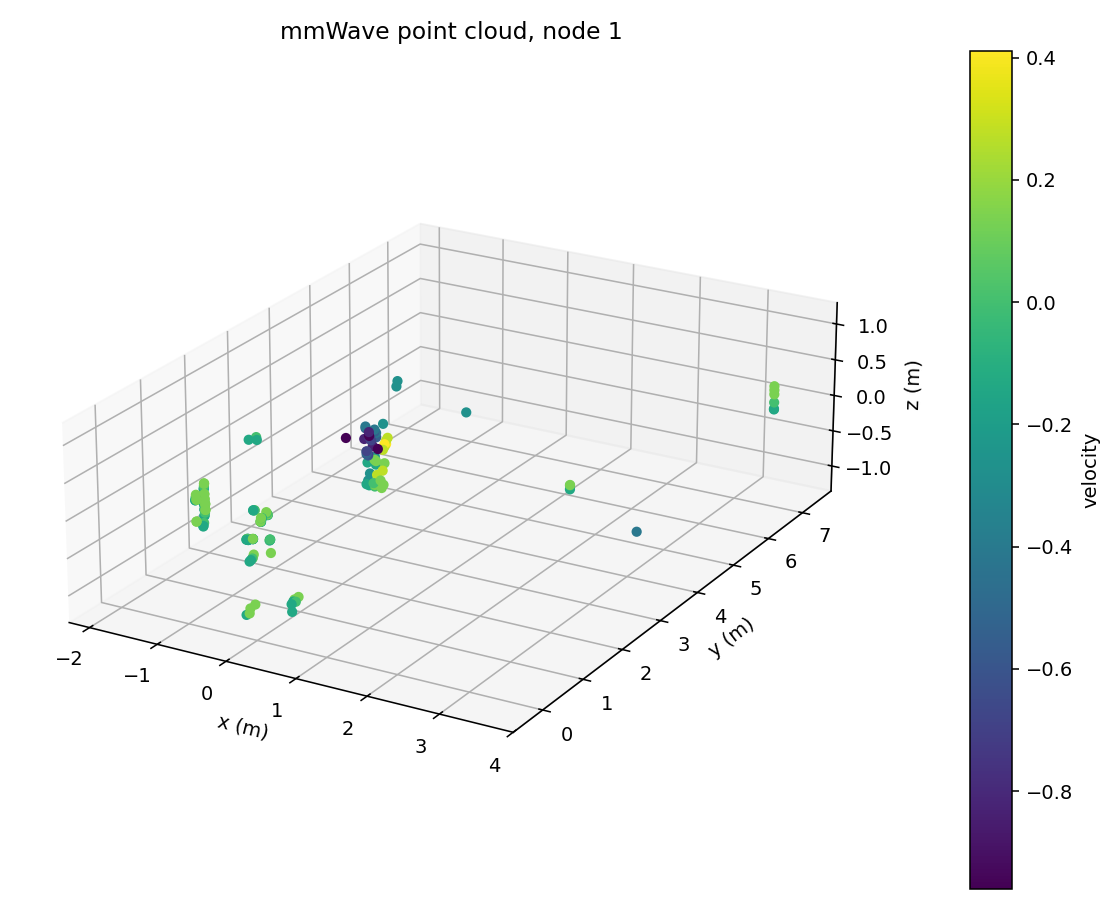

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'mmwave', 'mmWave point cloud, node 1')

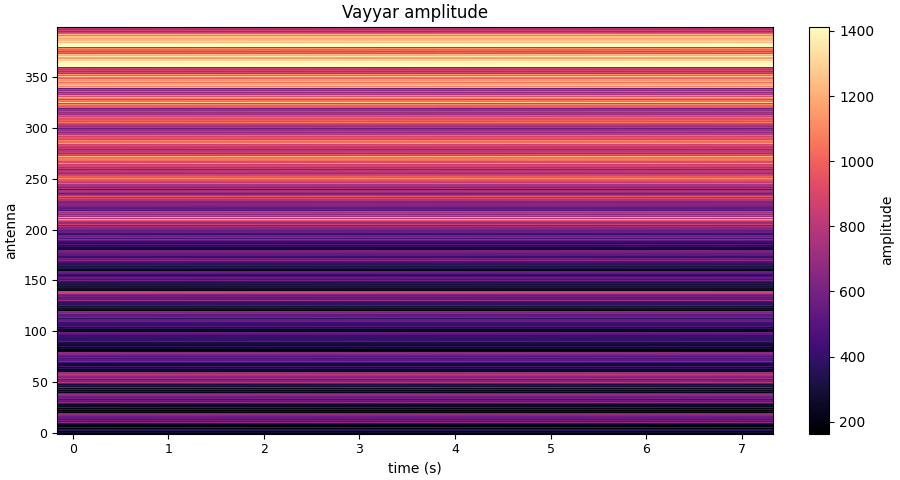

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'vayyar', 'Vayyar amplitude')


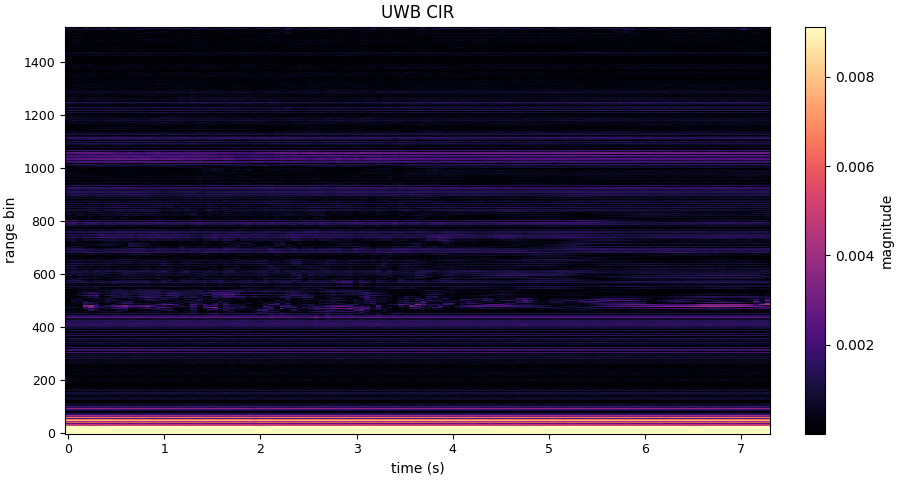

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'uwb', 'UWB CIR')


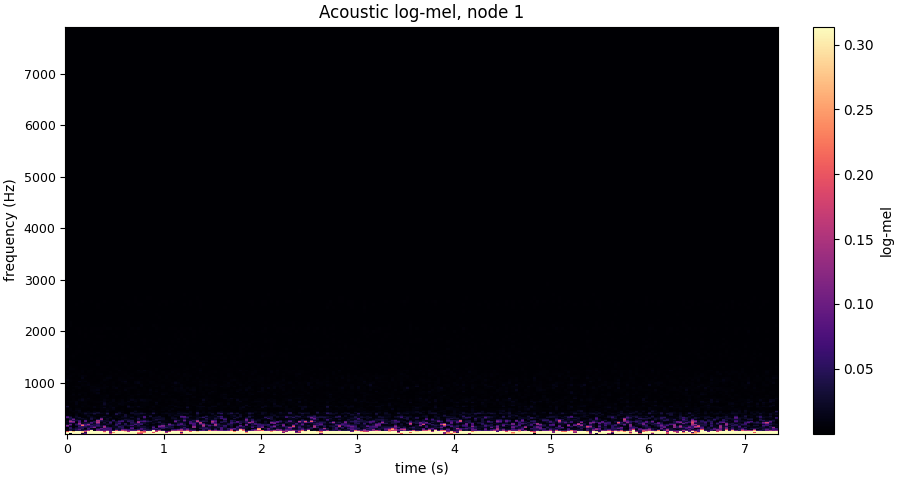

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'acoustic', 'Acoustic log-mel, node 1')


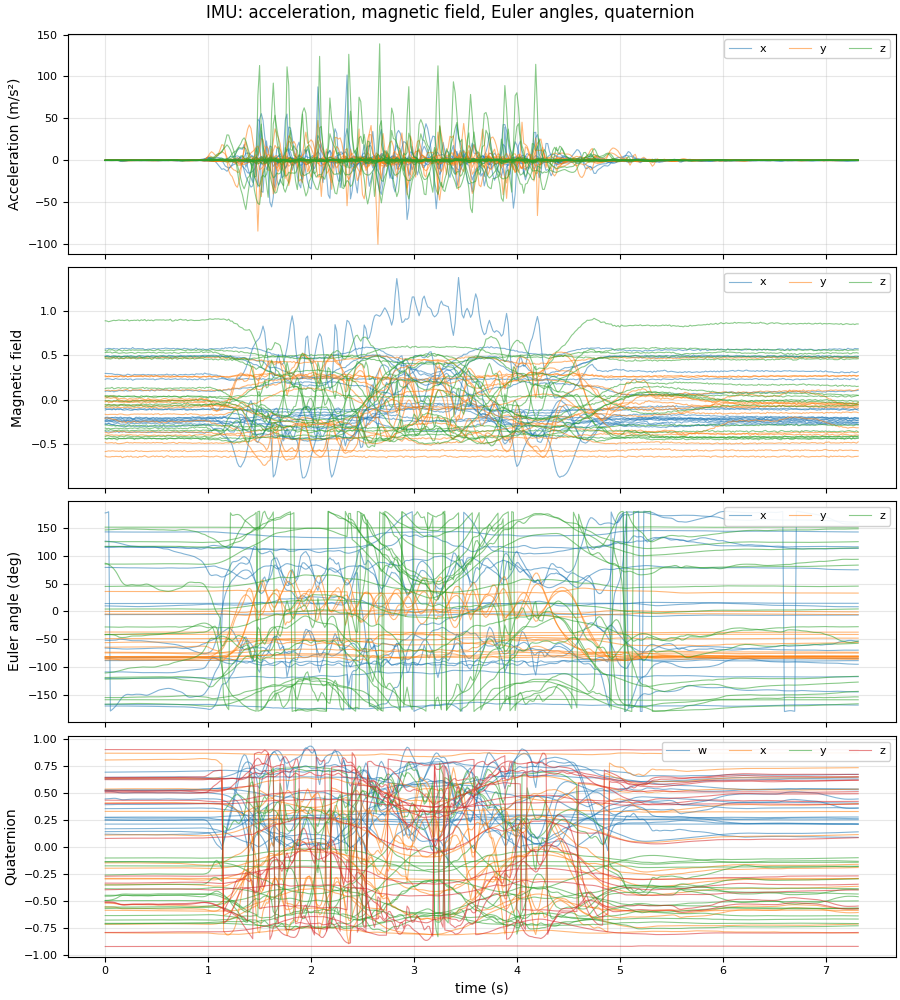

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'imu', 'IMU: acceleration, magnetic field, Euler angles, quaternion')


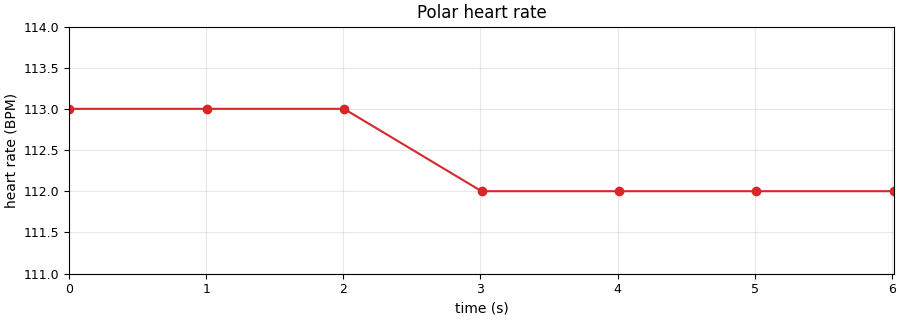

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'polar', 'Polar heart rate')


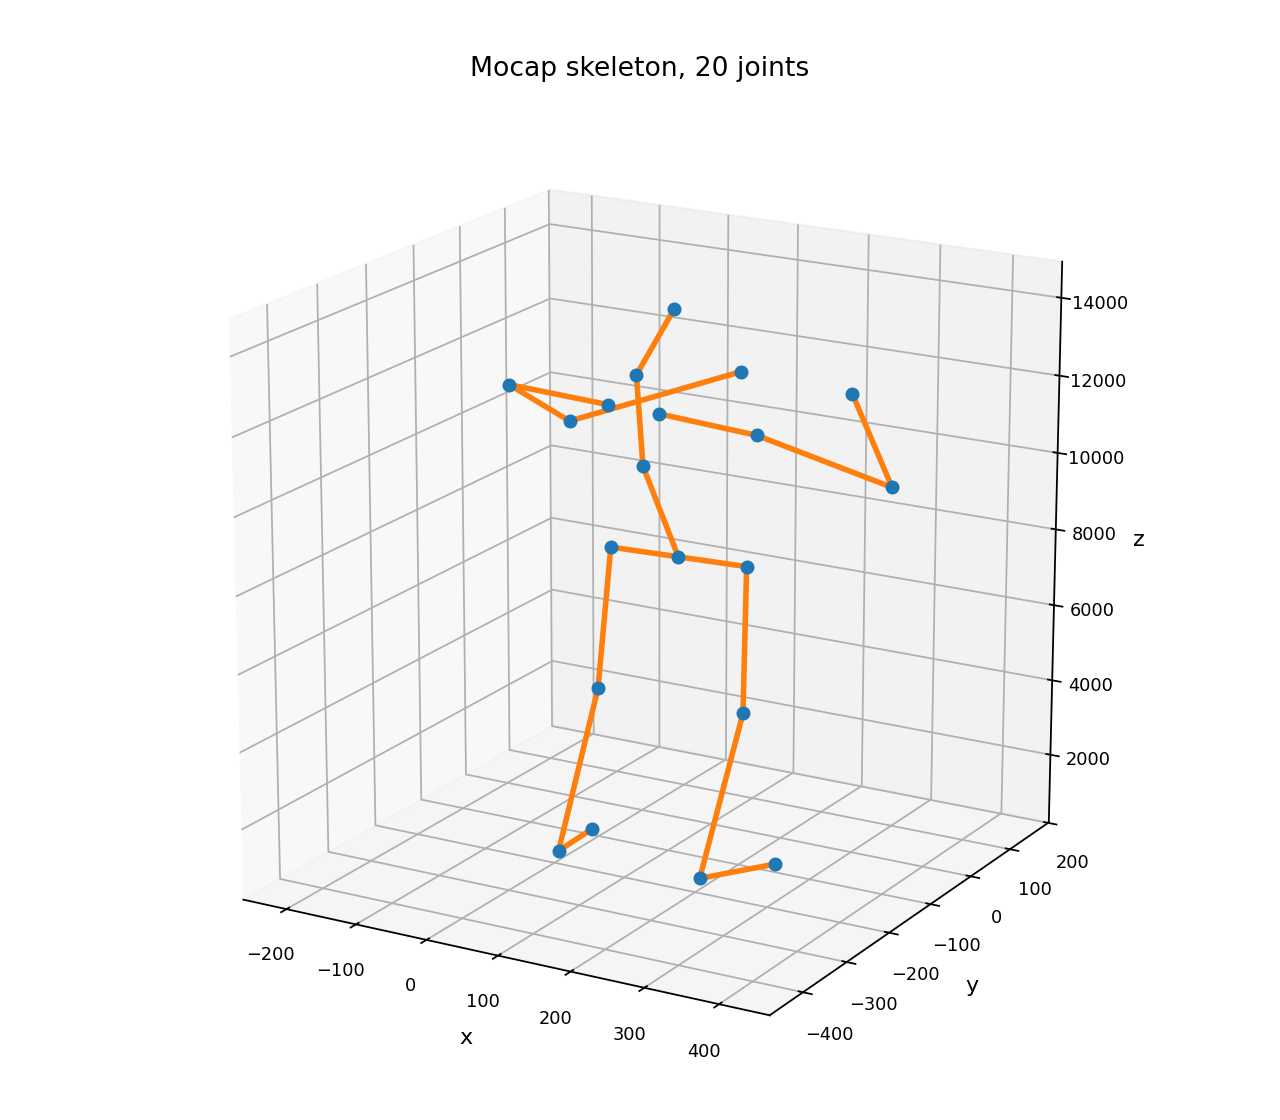

In [ ]:
from data_visualizer_new import show_keyframe

show_keyframe(clip, 'mocap', 'Mocap skeleton, 20 joints')
